In [2]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.mixture import GaussianMixture

In [3]:
data = pd.read_csv("weatherHistory.csv")
data

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [4]:
data["Precip Type"].unique(), data["Summary"].unique(), data["Daily Summary"].unique()

(array(['rain', 'snow', nan], dtype=object),
 array(['Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Foggy',
        'Breezy and Mostly Cloudy', 'Clear', 'Breezy and Partly Cloudy',
        'Breezy and Overcast', 'Humid and Mostly Cloudy',
        'Humid and Partly Cloudy', 'Windy and Foggy', 'Windy and Overcast',
        'Breezy and Foggy', 'Windy and Partly Cloudy', 'Breezy',
        'Dry and Partly Cloudy', 'Windy and Mostly Cloudy',
        'Dangerously Windy and Partly Cloudy', 'Dry', 'Windy',
        'Humid and Overcast', 'Light Rain', 'Drizzle', 'Windy and Dry',
        'Dry and Mostly Cloudy', 'Breezy and Dry', 'Rain'], dtype=object),
 array(['Partly cloudy throughout the day.',
        'Mostly cloudy throughout the day.', 'Foggy in the evening.',
        'Foggy overnight and breezy in the morning.',
        'Overcast throughout the day.', 'Partly cloudy until night.',
        'Mostly cloudy until night.',
        'Foggy starting overnight continuing until morning.',
        'Fo

# Preprosesamiento

In [5]:
df_encoded = data.copy()

- Conversion de variables categoricas

Codificamos la precipitacion en "Llovio" o "Nevo"

In [6]:
df_encoded = pd.get_dummies(data, columns=['Precip Type'], prefix='Precip')

In [7]:
df_encoded[["Precip_rain", "Precip_snow"]].sample(10)

,Precip_rain,Precip_snow
1489,True,False
74568,True,False
81238,False,True
1343,True,False
8693,True,False
15742,True,False
17940,True,False
18517,True,False
38454,False,True
56555,True,False


Codificamos la categoria "Summary" puntuado segun nubosidad, intensidad de viento, humedad y precipitacion

In [8]:
cloudy_map = {
    'Clear': 0,
    'Partly Cloudy': 1,
    'Mostly Cloudy': 2,
    'Overcast': 3,
    'Foggy': 4
}

wind_map = {
    'None': 0,
    'Breezy': 1,
    'Windy': 2,
    'Dangerously Windy': 3
}
humidity_map = {
    'None': 0,
    'Dry': 1,
    'Humid': 2
}

precip_map = {
    'None': 0,
    'Drizzle': 1,
    'Light Rain': 2,
    'Rain': 3
}

def extract_features(summary):
    cloud = None
    wind = 'None'
    humidity = 'None'
    precip = 'None'
  
    for cloud_type in ['Clear', 'Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Foggy']:
        if cloud_type in summary:
            cloud = cloud_type
            break
    
    # Buscar componente de viento
    if 'Dangerously Windy' in summary:
        wind = 'Dangerously Windy'
    elif 'Windy' in summary:
        wind = 'Windy'
    elif 'Breezy' in summary:
        wind = 'Breezy'
    
    # Buscar componente de humedad
    if 'Humid' in summary:
        humidity = 'Humid'
    elif 'Dry' in summary:
        humidity = 'Dry'
    
    # Buscar componente de precipitación
    if 'Rain' in summary and 'Light' not in summary:
        precip = 'Rain'
    elif 'Light Rain' in summary:
        precip = 'Light Rain'
    elif 'Drizzle' in summary:
        precip = 'Drizzle'
    
    return cloud, wind, humidity, precip

# Aplicar la función a cada resumen
df_encoded['cloud_value_hour'] = data['Summary'].apply(lambda x: cloudy_map.get(extract_features(x)[0], 0))
df_encoded['wind_value_hour'] = data['Summary'].apply(lambda x: wind_map.get(extract_features(x)[1], 0))
df_encoded['humidity_value_hour'] = data['Summary'].apply(lambda x: humidity_map.get(extract_features(x)[2], 0))
df_encoded['precip_value_hour'] = data['Summary'].apply(lambda x: precip_map.get(extract_features(x)[3], 0))

In [9]:
df_encoded[["Summary", "cloud_value_hour", "wind_value_hour", "humidity_value_hour", "precip_value_hour"]].sample(10)

,Summary,cloud_value_hour,wind_value_hour,humidity_value_hour,precip_value_hour
74927,Mostly Cloudy,2,0,0,0
8874,Clear,0,0,0,0
78075,Mostly Cloudy,2,0,0,0
5227,Clear,0,0,0,0
34020,Mostly Cloudy,2,0,0,0
30291,Clear,0,0,0,0
54338,Mostly Cloudy,2,0,0,0
84420,Breezy and Overcast,3,1,0,0
717,Partly Cloudy,1,0,0,0
6663,Mostly Cloudy,2,0,0,0


In [10]:
# Primero, vamos a crear una función para determinar la estación basada en la fecha
def get_season(date_str):
    # Extraer mes y día de la fecha formateada
    date_parts = date_str.split(' ')[0].split('-')
    month = int(date_parts[1])  # El mes estará en formato MM
    day = int(date_parts[2])    # El día estará en formato DD
    
    # Definir las estaciones según los meses
    # Primavera: marzo (3) a mayo (5)
    # Verano: junio (6) a agosto (8)
    # Otoño: septiembre (9) a noviembre (11)
    # Invierno: diciembre (12), enero (1), febrero (2)
    
    if (month == 3 and day >= 20) or (month == 4) or (month == 5) or (month == 6 and day < 21):
        return 'Primavera'
    elif (month == 6 and day >= 21) or (month == 7) or (month == 8) or (month == 9 and day < 22):
        return 'Verano'
    elif (month == 9 and day >= 22) or (month == 10) or (month == 11) or (month == 12 and day < 21):
        return 'Otoño'
    else:  # (month == 12 and day >= 21) or (month == 1) or (month == 2) or (month == 3 and day < 20)
        return 'Invierno'

# Crear el mapeo de estaciones a valores numéricos
season_map = {
    'Primavera': 0,
    'Verano': 1,
    'Otoño': 2,
    'Invierno': 3
}

# Aplicar la función y el mapeo para obtener la columna de estación
df_encoded['Season'] = data['Formatted Date'].apply(get_season).map(season_map)

# Para la hora, extraer de la columna 'Formatted Date'
# Esto es similar a lo que ya se está haciendo en el código original con 'y'
df_encoded['Hour'] = data['Formatted Date'].str.split(' ').str[1].str.split(':').str[0].astype(int)


In [11]:
df_encoded[["Season", "Hour"]].sample(10)

,Season,Hour
11479,3,7
90372,3,15
52593,1,9
78402,1,21
31254,1,6
78604,2,7
15346,0,11
77249,2,21
75445,3,16
47630,1,14


Convertimos la columna de "Precip Type" en la etiqueta

In [12]:
# Crear una nueva columna para la etiqueta de precipitación con 3 clases
def create_precip_label(precip_type):
    if pd.isna(precip_type):  # Si es NaN, significa sin precipitación
        return 0
    elif precip_type == 'rain':
        return 1
    elif precip_type == 'snow':
        return 2
    else:
        return 0  # Por si acaso hay algún otro valor no esperado

y = pd.DataFrame()

# Aplicar la función para crear la etiqueta
y['Precip_label'] = data['Precip Type'].apply(create_precip_label)

In [13]:
y.sample(5)

,Precip_label
56999,1
21072,2
76751,1
70761,1
58490,1


Eliminamos las columnas innecesarias

In [14]:
df_encoded.sample(5)

,Formatted Date,Summary,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Precip_rain,Precip_snow,cloud_value_hour,wind_value_hour,humidity_value_hour,precip_value_hour,Season,Hour
19250,2008-12-19 02:00:00.000 +0100,Overcast,4.905556,1.733333,0.89,14.4900,299.0,8.0500,0.0,1013.76,Overcast throughout the day.,True,False,3,0,0,0,2,2
79968,2015-08-22 03:00:00.000 +0200,Mostly Cloudy,16.644444,16.644444,0.93,5.9570,115.0,7.2128,0.0,1020.02,Mostly cloudy throughout the day.,True,False,2,0,0,0,1,3
54260,2012-12-16 20:00:00.000 +0100,Foggy,1.016667,1.016667,1.00,3.2683,94.0,0.3220,0.0,1015.59,Foggy starting in the morning.,True,False,4,0,0,0,2,20
23253,2008-03-31 22:00:00.000 +0200,Clear,8.194444,7.277778,0.61,6.4883,7.0,15.8263,0.0,1016.91,Clear throughout the day.,True,False,0,0,0,0,0,22
25152,2008-10-20 01:00:00.000 +0200,Foggy,4.977778,4.977778,0.93,3.0268,57.0,3.0590,0.0,1026.30,Foggy starting overnight continuing until morn...,True,False,4,0,0,0,2,1


In [15]:
df_encoded.drop(columns=["Formatted Date", "Summary", "Daily Summary", "Precip_rain", "Precip_snow"], inplace=True)

In [16]:
df_encoded.sample(10)

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),cloud_value_hour,wind_value_hour,humidity_value_hour,precip_value_hour,Season,Hour
86300,7.466667,6.500000,0.80,6.2629,219.0,11.8013,0.0,1020.73,3,0,0,0,2,0
44711,18.655556,18.655556,0.83,3.0107,156.0,14.9569,0.0,1011.53,2,0,0,0,1,23
62423,20.844444,20.844444,0.73,17.6617,314.0,14.9569,0.0,1018.41,2,0,0,0,1,23
43296,14.377778,14.377778,0.93,3.2200,100.0,11.8013,0.0,1014.45,2,0,0,0,1,0
31891,9.200000,7.505556,0.48,11.0768,203.0,9.9820,0.0,1010.22,1,0,0,0,0,19
30544,31.111111,30.050000,0.32,16.1000,0.0,11.2700,0.0,1016.10,1,0,0,0,1,16
90831,-2.266667,-5.861111,0.67,9.4990,101.0,9.9820,0.0,1020.88,2,0,0,0,3,18
66044,15.911111,15.911111,0.79,10.5455,283.0,11.4471,0.0,1009.31,1,0,0,0,0,20
95481,11.783333,11.783333,0.55,2.0608,299.0,0.0000,0.0,1033.77,0,0,0,0,2,13
9830,31.616667,30.755556,0.33,21.1715,190.0,9.9820,0.0,1008.56,1,0,0,0,1,14


Separamos un 10% de los datos para validacion

In [17]:
X_train, X_test, y_train, y_test = train_test_split(df_encoded, y, test_size=0.1, random_state=42)

In [18]:
X_train.head(1)

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),cloud_value_hour,wind_value_hour,humidity_value_hour,precip_value_hour,Season,Hour
88408,23.911111,23.911111,0.69,9.6439,319.0,10.2557,0.0,1014.36,2,0,0,0,1,19


In [19]:
y_train.head(1)

,Precip_label
88408,1


# DBSCAN

Aplicamos DBSCAN para Aprendizaje No Supervisado

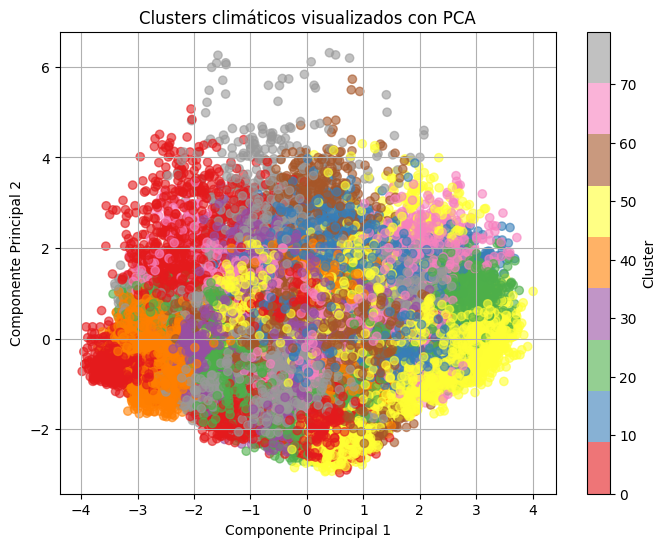

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']
X = df_encoded[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=80, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', alpha=0.6)
plt.title("Clusters climáticos visualizados con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

- Escalamiento para el uso del algoritmo:

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [22]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan.fit(X_scaled)
np.unique(dbscan.labels_)

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
       142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
       168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 17

In [23]:
dbscan2 = DBSCAN(eps=0.035)
dbscan2.fit(X_scaled)
np.unique(dbscan2.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16], dtype=int64)

In [24]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)

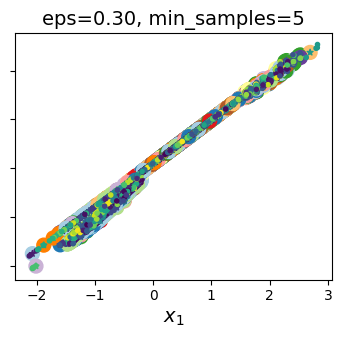

In [25]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X_scaled[:, :2], size=100, show_ylabels=False)

plt.show()

In [26]:

knn = KNeighborsClassifier()
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])


KNeighborsClassifier()

# Gaussian Mixtures

In [27]:
gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X_scaled)

GaussianMixture(n_components=3, n_init=10, random_state=42)

In [28]:
gm.weights_

array([0.44343742, 0.52599855, 0.03056403])

In [29]:
gm.means_

array([[-0.83729898, -0.85385414,  0.52206452, -0.03411213, -0.04457341,
        -0.47291537,  0.        ,  0.13392752,  0.38118231, -0.12859701,
        -0.04297215,  0.04060665,  0.68242496, -0.09135183],
       [ 0.71611247,  0.73610466, -0.42685634, -0.08757875,  0.02264361,
         0.40922248,  0.        ,  0.10468457, -0.31304065, -0.12859701,
         0.03804052, -0.03235307, -0.58935442,  0.07395909],
       [-0.1761685 , -0.28003858, -0.22827909,  2.00212132,  0.25700189,
        -0.18132612,  0.        , -3.74467718, -0.14302988,  4.07886598,
        -0.03120669, -0.03235307,  0.24168316,  0.05256013]])

In [30]:
gm.covariances_

array([[[ 4.08382240e-01,  4.12366974e-01, -1.03497006e-01,
          4.66242300e-02,  1.76701833e-02,  1.54829879e-01,
          0.00000000e+00, -1.64128126e-02, -9.95637961e-02,
          3.12157138e-29,  1.08388631e-29,  4.71754954e-02,
         -2.31353691e-01,  4.96228186e-02],
        [ 4.12366974e-01,  4.38258793e-01, -8.22626733e-02,
         -6.88008007e-02,  1.58701540e-02,  1.08520084e-01,
          0.00000000e+00, -1.33342524e-02, -8.79919102e-02,
          3.09484136e-29,  1.07564618e-29,  4.86768994e-02,
         -2.36469198e-01,  4.65621466e-02],
        [-1.03497006e-01, -8.22626733e-02,  4.22709186e-01,
         -1.77090474e-01, -2.69355116e-03, -3.95582446e-01,
          0.00000000e+00, -2.10976950e-03,  2.88551677e-01,
         -1.95134984e-29, -6.77907303e-30,  2.10566603e-02,
          5.42369471e-02, -1.08733174e-01],
        [ 4.66242300e-02, -6.88008007e-02, -1.77090474e-01,
          7.91120605e-01,  3.28334559e-02,  3.17010830e-01,
          0.00000000e+00, -2

In [31]:
X_new, y_new = gm.sample(6)
X_new

array([[-7.52236304e-01, -7.08187722e-01,  9.91335480e-01,
        -1.66724589e-01,  1.22667990e+00, -2.20715681e+00,
        -7.10687391e-04,  1.48941872e-01,  2.34386998e+00,
        -1.26226489e-01, -4.20623527e-02,  4.92038248e-01,
         1.08464331e+00, -3.11645557e-01],
       [-2.59348224e-01, -1.89255004e-01,  3.99634461e-01,
        -9.92768326e-01,  1.32953030e+00, -2.79581830e-01,
        -2.81453467e-04,  1.25194697e-01,  4.80512222e-01,
        -1.28745828e-01, -4.22752687e-02,  1.52208808e+00,
        -9.53676922e-01, -6.47259937e-03],
       [-1.03265446e-01,  2.59253672e-02,  1.24717980e-01,
        -5.84148767e-01,  3.62926475e-01,  3.51698329e-02,
        -2.90198785e-04,  1.06020362e-01, -8.62587476e-01,
        -1.28407767e-01,  1.95497918e+00, -3.24687338e-02,
        -1.91228732e+00, -1.69463471e+00],
       [ 1.20447426e+00,  1.18548770e+00, -1.83281833e+00,
         5.24833684e-01, -9.03234785e-01, -1.98982492e-01,
        -2.52371491e-04,  6.21223698e-02,  4.

In [32]:
densities = gm.score_samples(X_scaled)
density_threshold = np.percentile(densities, 4)
anomalies = X_scaled[densities < density_threshold]

 # Bayesian Gauss Mixtures

In [33]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X_scaled)

c:\Users\ltron\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)

In [34]:
np.round(bgm.weights_, 2)

array([0.07, 0.56, 0.11, 0.01, 0.  , 0.02, 0.04, 0.17, 0.01, 0.  ])

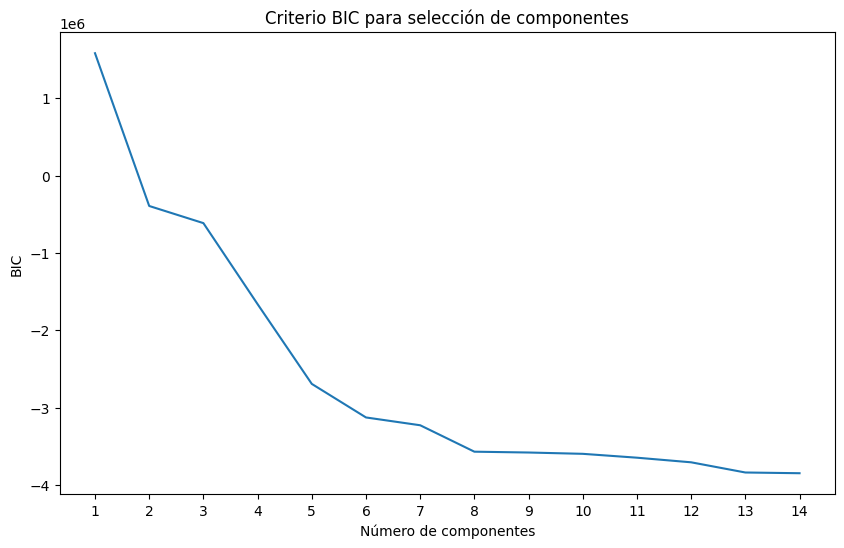

In [35]:
from sklearn.mixture import GaussianMixture
import numpy as np

# Calcular BIC para diferentes números de componentes
n_components = np.arange(1, 15)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled) for n in n_components]
bic = [m.bic(X_scaled) for m in models]

plt.figure(figsize=(10, 6))
plt.plot(n_components, bic)
plt.title('Criterio BIC para selección de componentes')
plt.xlabel('Número de componentes')
plt.ylabel('BIC')
plt.xticks(n_components)
plt.show()

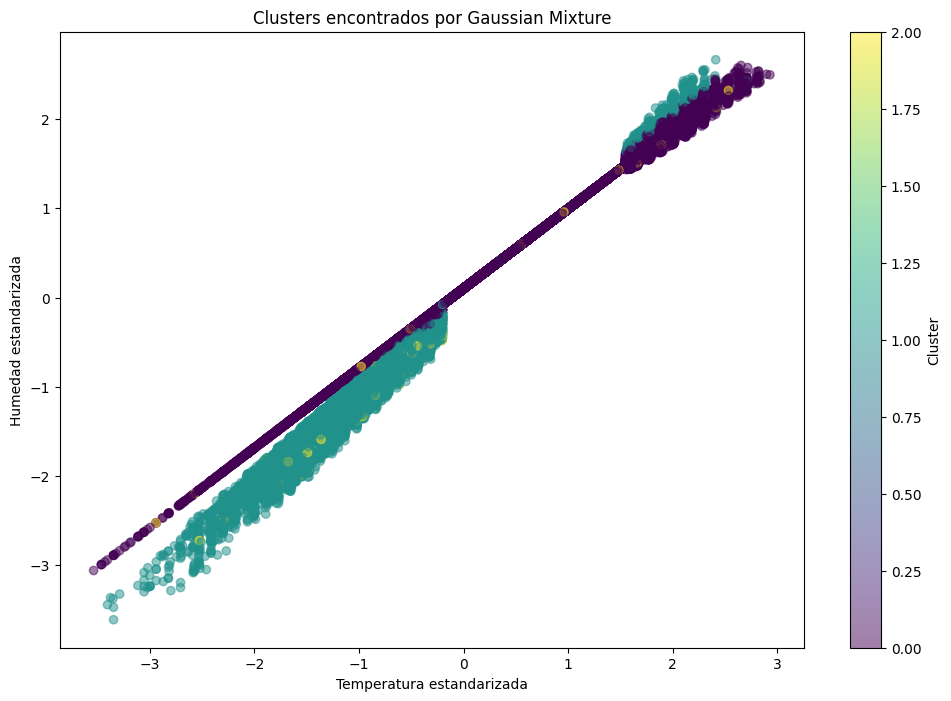

In [36]:
# Ajustar el modelo con el número óptimo de componentes
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm_clusters = gmm.fit_predict(X_scaled)

# Visualizar los clusters
plt.figure(figsize=(12, 8))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_clusters, cmap='viridis', alpha=0.5)
plt.title('Clusters encontrados por Gaussian Mixture')
plt.xlabel('Temperatura estandarizada')
plt.ylabel('Humedad estandarizada')
plt.colorbar(label='Cluster')
plt.show()